# Exercise Sheet 9 — Anomaly / OOD Detection

**Exercises covered:**

| Exercise | Topic |
|----------|-------|
| 9.1 | Conceptual: why classifiers cannot self-report OOD |
| 9.2 | MSP baseline description + limitations |
| 9.3 | Energy-score as advanced alternative |
| 9.4 | Visualise distribution shift (sunny vs fog vs night vs new town) |
| 9.5 | Is the different-town data OOD? |
| 9.6 | Evaluate MSP baseline (AUROC per OOD scenario) |
| 9.7 | Feature-based detector (Mahalanobis distance) vs MSP |
| 9.8 | Extend STPA safety analysis for OOD risk |

**Models used** (loaded directly from Drive — no retraining):
- `MyDrive/CARLA_DATASET/models/pedestrian_model.pth`
- `MyDrive/CARLA_DATASET/models/traffic_light_model.pth`
- `MyDrive/CARLA_DATASET/models/vehicle_model.pth`

## ⚙️ Cell 1 — Mount Drive & install dependencies

In [14]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torch torchvision matplotlib numpy Pillow scikit-learn seaborn

import os, csv, random, glob, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.neighbors import NearestNeighbors
from sklearn.covariance import EmpiricalCovariance

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
os.makedirs('/content/results', exist_ok=True)
print('✓ Ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
✓ Ready.


## 📁 Cell 2 — Paths CONFIG (edit if your folder layout differs)

In [16]:
# ── Dataset root ────────────────────────────────────────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive/CARLA_DATASET'

# In-distribution (sunny / daytime — the training distribution)
ID_IMG_DIR  = os.path.join(DRIVE_ROOT, 'test',       'rgb-front')
ID_CSV      = os.path.join(DRIVE_ROOT, 'test',       'labels.csv')

# OOD splits
FOG_IMG_DIR   = os.path.join(DRIVE_ROOT, 'test-fog',   'rgb-front')
FOG_CSV       = os.path.join(DRIVE_ROOT, 'test-fog',   'labels.csv')
NIGHT_IMG_DIR = os.path.join(DRIVE_ROOT, 'test-night', 'rgb-front')
NIGHT_CSV     = os.path.join(DRIVE_ROOT, 'test-night', 'labels.csv')
TOWN_IMG_DIR  = os.path.join(DRIVE_ROOT, 'test-town-01', 'rgb-front')
TOWN_CSV      = os.path.join(DRIVE_ROOT, 'test-town-01', 'labels.csv')

# ── Model checkpoints (directly from Drive) ─────────────────────────────────
MODEL_DIR = os.path.join(DRIVE_ROOT, 'models')
MODEL_PATHS = {
    'pedestrian':    os.path.join(MODEL_DIR, 'pedestrian_model.pth'),
    'traffic_light': os.path.join(MODEL_DIR, 'traffic_light_model.pth'),
    'vehicle':       os.path.join(MODEL_DIR, 'vehicle_model.pth'),
}

# ── CSV columns ──────────────────────────────────────────────────────────────
FNAME_COL = 'frame'
TASK_COLS = {
    'pedestrian':    'has_pedestrian',
    'traffic_light': 'has_traffic_light',
    'vehicle':       'has_vehicle',
}
TASKS    = list(TASK_COLS.keys())
IMG_SIZE = (224, 224)
BATCH    = 64

# ── Auto-detect filename format ──────────────────────────────────────────────
def build_frame_fn(img_dir, csv_path):
    """Return frame_val -> filename function matched to actual files."""
    with open(csv_path) as f:
        sample = next(csv.DictReader(f))[FNAME_COL]
    n       = int(float(sample))
    actual  = sorted(os.listdir(img_dir))[:6]
    matched = None
    for fn in actual:
        stem = os.path.splitext(fn)[0]
        try:
            if int(stem) == n: matched = fn; break
        except ValueError:
            if str(n) in stem: matched = fn; break
    if matched is None: matched = actual[0]
    ext    = os.path.splitext(matched)[1]
    stem_m = os.path.splitext(matched)[0]

    def frame_to_filename(frame_val):
        num = int(float(frame_val))
        if stem_m.isdigit():
            return str(num).zfill(len(stem_m)) + ext
        prefix = stem_m.rstrip('0123456789')
        pad    = len(stem_m) - len(prefix)
        return prefix + str(num).zfill(pad) + ext
    return frame_to_filename

# Build one function per split (only for splits that exist)
SPLITS = {}
for name, img_dir, csv_path in [
    ('ID',    ID_IMG_DIR,    ID_CSV),
    ('fog',   FOG_IMG_DIR,   FOG_CSV),
    ('night', NIGHT_IMG_DIR, NIGHT_CSV),
    ('town',  TOWN_IMG_DIR,  TOWN_CSV),
]:
    if os.path.exists(csv_path) and os.path.isdir(img_dir):
        SPLITS[name] = {
            'img_dir': img_dir,
            'csv':     csv_path,
            'fn':      build_frame_fn(img_dir, csv_path),
        }
        print(f'  ✓ {name:<6}  {len(os.listdir(img_dir)):>5} images')
    else:
        print(f'  ✗ {name:<6}  NOT FOUND (skip)')

OOD_NAMES = [k for k in SPLITS if k != 'ID']
print('\nModel paths:')
for task, path in MODEL_PATHS.items():
    print(f'  {"✓" if os.path.exists(path) else "✗"} {path}')

  ✓ ID       3600 images
  ✓ fog      3600 images
  ✓ night    3602 images
  ✓ town     3601 images

Model paths:
  ✓ /content/drive/MyDrive/CARLA_DATASET/models/pedestrian_model.pth
  ✓ /content/drive/MyDrive/CARLA_DATASET/models/traffic_light_model.pth
  ✓ /content/drive/MyDrive/CARLA_DATASET/models/vehicle_model.pth


## 🧠 Cell 3 — Load models (no retraining)

In [17]:
def build_resnet18():
    m = tv_models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m.to(DEVICE)

MODELS = {}
for task, path in MODEL_PATHS.items():
    ckpt = torch.load(path, map_location=DEVICE)
    m    = build_resnet18()
    # support both raw state_dict and wrapped checkpoint
    state = ckpt.get('model_state_dict', ckpt)
    m.load_state_dict(state)
    m.eval()
    MODELS[task] = m
    val_acc = ckpt.get('final_val_acc', '?')
    print(f'  ✓ {task:<16}  val_acc={val_acc}')

print('\n✓ All 3 models loaded (no training).')

  ✓ pedestrian        val_acc=0.7711111111111111
  ✓ traffic_light     val_acc=0.9441666666666667
  ✓ vehicle           val_acc=0.8930555555555556

✓ All 3 models loaded (no training).


## 📐 Cell 4 — Shared dataset + feature-extraction utilities

In [18]:
EVAL_TF = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CARLADataset(Dataset):
    def __init__(self, img_dir, csv_path, task, frame_fn, transform=EVAL_TF):
        self.img_dir   = img_dir
        self.transform = transform
        self.samples   = []
        col = TASK_COLS[task]
        with open(csv_path, newline='') as f:
            for row in csv.DictReader(f):
                fname = frame_fn(row[FNAME_COL])
                raw   = row[col].strip().upper()
                label = 1 if raw in ('TRUE', '1', '1.0') else 0
                self.samples.append((fname, label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.transform(img), torch.tensor(label, dtype=torch.float32)


def make_loader(split_name, task):
    s = SPLITS[split_name]
    ds = CARLADataset(s['img_dir'], s['csv'], task, s['fn'])
    return DataLoader(ds, batch_size=BATCH, shuffle=False,
                      num_workers=2, pin_memory=True)


# ── MSP scores ───────────────────────────────────────────────────────────────
@torch.no_grad()
def get_msp_scores(model, loader):
    """Return list of MSP values (higher = more in-distribution)."""
    scores = []
    for imgs, _ in loader:
        imgs  = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs)).cpu().squeeze(1)
        # For binary classifier: MSP = max(p, 1-p)
        msp   = torch.max(probs, 1 - probs)
        scores.extend(msp.tolist())
    return np.array(scores)


# ── Deep feature extraction (penultimate layer = avgpool output) ──────────────
def get_feature_extractor(model):
    """Wrap model to return 512-d avgpool features instead of logit."""
    class FeatureModel(nn.Module):
        def __init__(self, base):
            super().__init__()
            self.features = nn.Sequential(
                base.conv1, base.bn1, base.relu, base.maxpool,
                base.layer1, base.layer2, base.layer3, base.layer4,
                base.avgpool,
            )
        def forward(self, x):
            return self.features(x).flatten(1)
    return FeatureModel(model).to(DEVICE).eval()


@torch.no_grad()
def extract_features(feat_model, loader):
    feats = []
    for imgs, _ in loader:
        feats.append(feat_model(imgs.to(DEVICE)).cpu().numpy())
    return np.concatenate(feats, axis=0)

print('✓ Utilities defined.')

✓ Utilities defined.


---
## 📝 Exercises 9.1 – 9.3: Conceptual Questions

### Exercise 9.1 — The OOD Problem

**Q1. Why can a standard classifier not be trusted to signal when it receives an OOD input?**

A standard classifier is trained to partition input space into $K$ classes by optimising cross-entropy on the *training distribution*. The softmax function is defined over all of $\mathbb{R}^K$ and normalises the output to sum to 1 — meaning it must assign *some* class probability to *every* input, including inputs it has never seen. The decision boundary is learned only where training data exists; outside that region the network extrapolates arbitrarily, often producing high-confidence class probabilities for unrelated inputs (a well-known failure mode demonstrated in the lecture slide showing random textures classified as traffic signs with > 96% confidence). There is no "reject" class and no mechanism to measure how different a new input is from the training distribution.

**Q2. Why is silent failure (confidently wrong prediction) worse than uncertain failure in a safety-critical system?**

In a safety-critical system a downstream *planner* acts on perception outputs. If the perception model produces a low-confidence output, the planner (or a supervisory monitor) can detect the uncertainty and fall back to a safe action — slow down, request human intervention, or stop. A *confidently wrong* prediction, however, looks identical to a correct prediction from the planner's perspective. There is no signal to trigger the safe fallback, so the system will act on bad information at full speed. The result is a hazard with no safety net: e.g. the vehicle continues at speed because the pedestrian detector confidently reports "no pedestrian" on a fog-occluded scene.

---
### Exercise 9.2 — MSP Baseline

**Maximum Softmax Probability (MSP)** (Hendrycks & Gimpel, 2017) uses the classifier's own output as an OOD score. For a binary classifier the score is:

$$D(x) = -\max_y\, p(y \mid x) = -\max(\sigma(f(x)),\; 1 - \sigma(f(x)))$$

Low confidence $\Rightarrow$ high outlier score. **Advantages:** zero additional cost, trivial to implement, no extra data required. **Limitations:**
- Softmax is overconfident by construction — even OOD inputs receive high probabilities (see lecture slide: random zigzag texture → 'Priority Road' 100 %).
- The score is not aligned with the data density $p(x)$; it reflects the decision boundary, not the support of the training distribution.
- Binary classifiers make the issue worse: max(p, 1−p) ≥ 0.5 always, so the dynamic range for OOD separation is only [0.5, 1.0].

---
### Exercise 9.3 — Energy Score

**Energy-Based OOD Detection** (Liu et al., 2020) uses the *free energy* of the network's logits:

$$D(x) = -\log \sum_{i=1}^{K} e^{f_i(x)}$$

**Why better than MSP:**  
The energy is theoretically aligned with $-\log p(x)$ via the Gibbs distribution — it measures how much probability mass the network assigns to the input *before* normalisation. For OOD inputs the unnormalised logits tend to be uniformly low, yielding high (less negative) energy scores. MSP collapses this information through the softmax normalisation, discarding the magnitude of the logits. Energy preserves that magnitude, giving better separation between ID and OOD even when MSP is saturated near 1.0.

---
## 🖼️ Cell 5 — Exercise 9.4: Visualise distribution shift

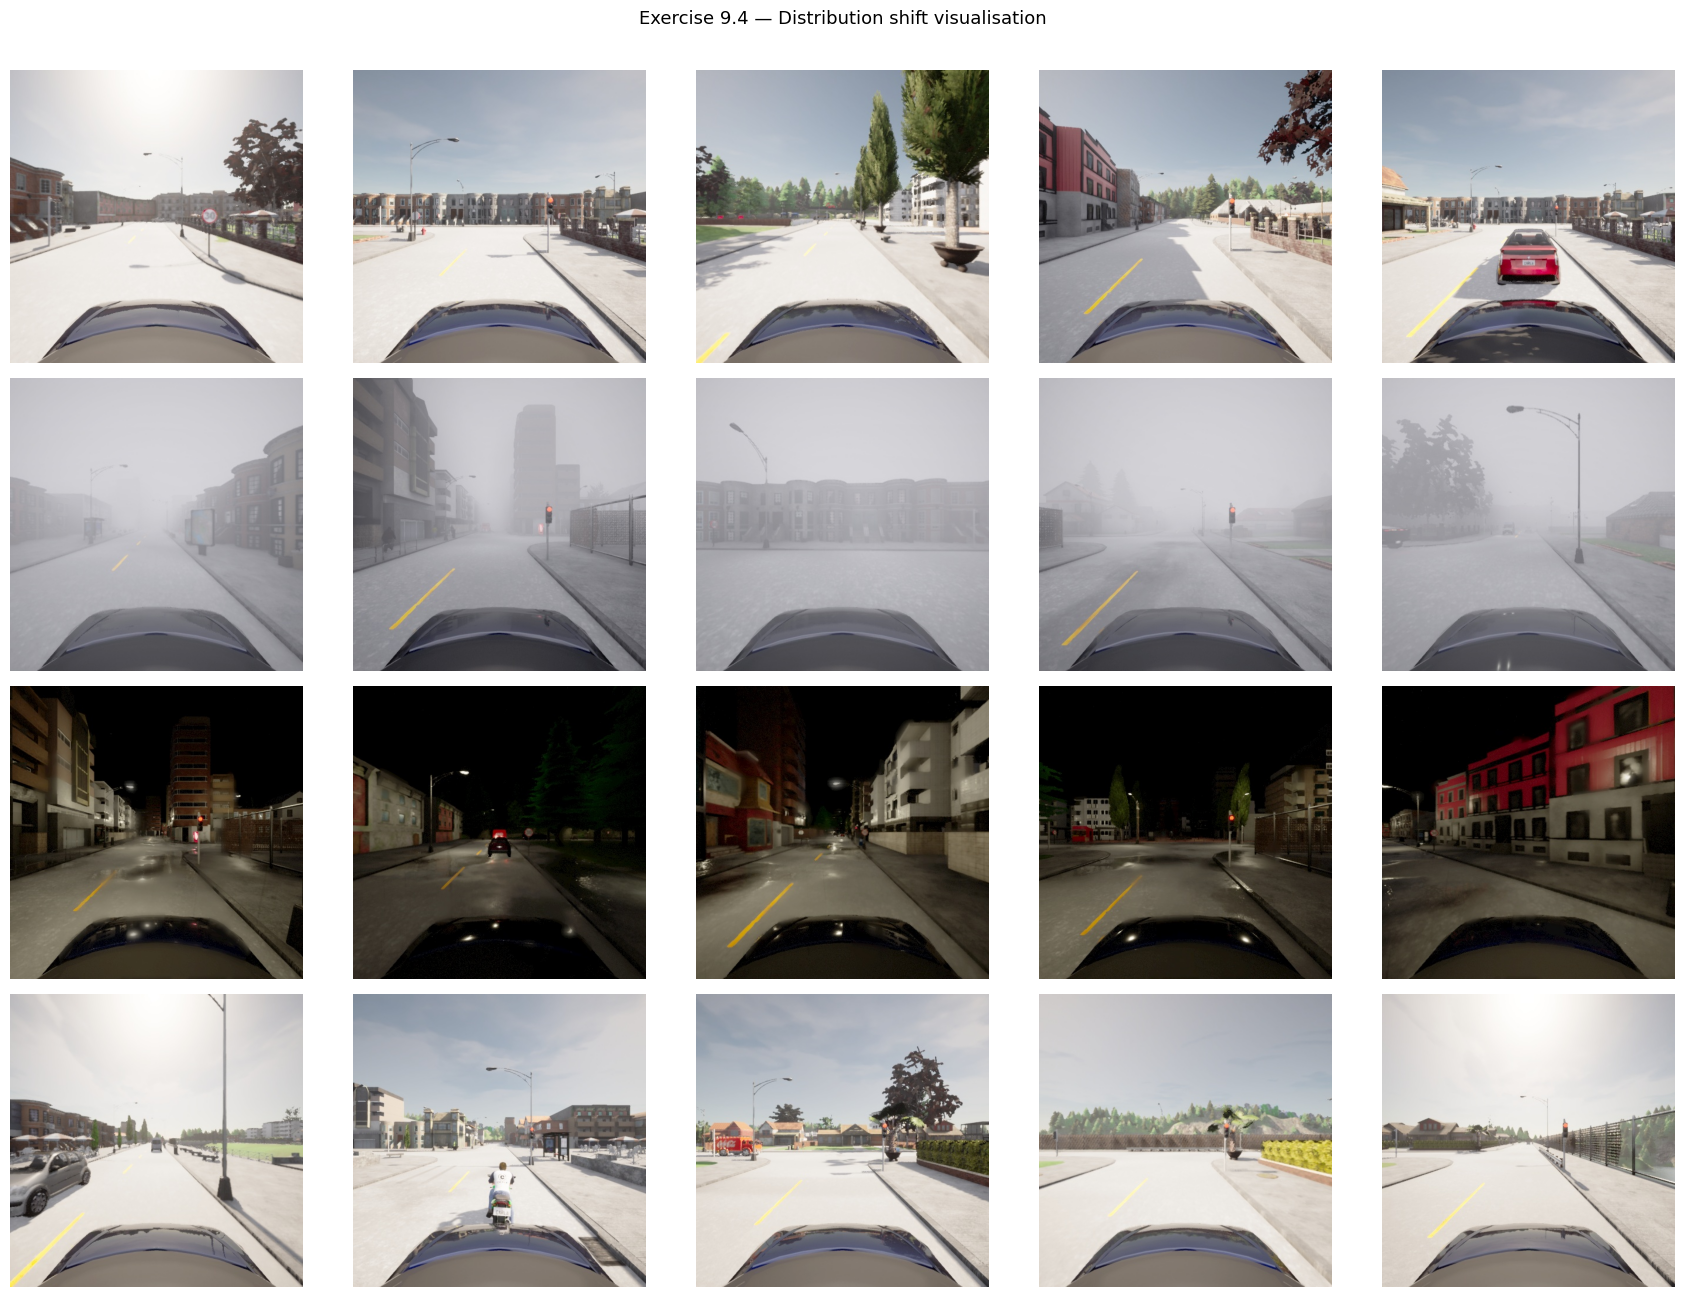


─── Exercise 9.4.2 — New-town images vs fog/night ──────────────────────────
Fog and night images have strong PERCEPTUAL shifts: fog reduces contrast and
introduces haze; night dramatically changes brightness, colour temperature,
and introduces artificial light sources. Both are immediately visible to a
human observer as abnormal.

New-town images share the same weather/lighting as training but differ in
SCENE STRUCTURE: building architecture, road geometry, vegetation species,
junction layouts, and signage. The shift is subtler — images can look
superficially similar — but the distribution of object appearances,
backgrounds, and spatial layouts has changed. This is covariate shift
in scene context rather than image-level appearance.
────────────────────────────────────────────────────────────────────────────



In [19]:
def load_csv_rows(path):
    with open(path) as f:
        return list(csv.DictReader(f))

n_show = 5
split_labels = {
    'ID':    ('In-distribution (Sunny/Day)', ID_IMG_DIR,    ID_CSV,    SPLITS['ID']['fn']),
}
for name in OOD_NAMES:
    s = SPLITS[name]
    split_labels[name] = (f'OOD — {name}', s['img_dir'], s['csv'], s['fn'])

n_rows = len(split_labels)
fig, axes = plt.subplots(n_rows, n_show, figsize=(3.5 * n_show, 3.2 * n_rows))
if n_rows == 1: axes = axes[np.newaxis, :]

for row_i, (split_name, (title, img_dir, csv_path, fn)) in enumerate(split_labels.items()):
    rows   = load_csv_rows(csv_path)
    sample = random.sample(rows, min(n_show, len(rows)))
    for col_i, row in enumerate(sample):
        fname = fn(row[FNAME_COL])
        img   = Image.open(os.path.join(img_dir, fname)).convert('RGB')
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].axis('off')
        if col_i == 0:
            axes[row_i, col_i].set_ylabel(title, fontsize=9, rotation=0,
                                          labelpad=120, va='center')

plt.suptitle('Exercise 9.4 — Distribution shift visualisation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/content/results/9_4_distribution_shift.png', dpi=130, bbox_inches='tight')
plt.show()

print("""
─── Exercise 9.4.2 — New-town images vs fog/night ──────────────────────────
Fog and night images have strong PERCEPTUAL shifts: fog reduces contrast and
introduces haze; night dramatically changes brightness, colour temperature,
and introduces artificial light sources. Both are immediately visible to a
human observer as abnormal.

New-town images share the same weather/lighting as training but differ in
SCENE STRUCTURE: building architecture, road geometry, vegetation species,
junction layouts, and signage. The shift is subtler — images can look
superficially similar — but the distribution of object appearances,
backgrounds, and spatial layouts has changed. This is covariate shift
in scene context rather than image-level appearance.
────────────────────────────────────────────────────────────────────────────
""")

---
## 🏙️ Cell 6 — Exercise 9.5: Is the different town OOD?

In [20]:
print("""
═══════════════════════════════════════════════════════════════════════════════
Exercise 9.5 — Is the different town OOD?
═══════════════════════════════════════════════════════════════════════════════

9.5.1  Original ODD (from Exercise 2.2):
  "The system operates on paved urban roads in sunny daytime conditions in
   CARLA Town01, at speeds below 50 km/h, with a front-facing RGB camera."

  → The ODD explicitly names Town01. Town2 images are therefore OUTSIDE
    the ODD as written — but the decision is ambiguous because the wording
    could be read as exemplary rather than exhaustive.

9.5.2  Revised ODD (chosen: new town is INSIDE the ODD):
  "The system operates on paved urban roads in clear sunny daytime conditions
   in any CARLA simulated environment, at speeds below 50 km/h, with a
   front-facing RGB camera under standard rendering settings."

  Rationale: The operational intent is urban autonomous driving, not
  Town01-specific deployment. Weather and lighting are the safety-critical
  constraints (fog, night create genuine sensor degradation); town layout
  differences are expected operational variation that the system must handle.
  Excluding all unseen towns would make deployment impossible.

9.5.3  Implications:
  By placing the new town INSIDE the ODD, the system MUST classify new-town
  images correctly — they are valid operational inputs, not edge cases to
  reject. An OOD monitor should NOT flag these images. Instead, if models
  underperform on them, the right response is to expand the training set
  (fine-tune on new-town data) rather than deploy a monitor to reject them.
  The fog/night images remain clearly OUTSIDE the ODD and should be flagged
  by an OOD monitor so the system can trigger a safe fallback behaviour.
═══════════════════════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════════════════════
Exercise 9.5 — Is the different town OOD?
═══════════════════════════════════════════════════════════════════════════════

9.5.1  Original ODD (from Exercise 2.2):
  "The system operates on paved urban roads in sunny daytime conditions in
   CARLA Town01, at speeds below 50 km/h, with a front-facing RGB camera."

  → The ODD explicitly names Town01. Town2 images are therefore OUTSIDE
    the ODD as written — but the decision is ambiguous because the wording
    could be read as exemplary rather than exhaustive.

9.5.2  Revised ODD (chosen: new town is INSIDE the ODD):
  "The system operates on paved urban roads in clear sunny daytime conditions
   in any CARLA simulated environment, at speeds below 50 km/h, with a
   front-facing RGB camera under standard rendering settings."

  Rationale: The operational intent is urban autonomous driving, not
  Town01-specific deployment. Weather and lighting are the saf

---
## 📊 Cell 7 — Exercise 9.4.3: Mean softmax confidence per split

Reference model: pedestrian
  Split           Mean MSP     Std MSP       N
------------------------------------------------------------
  ID                0.8862      0.1344    3600
  fog               0.8615      0.1471    3600
  night             0.8240      0.1424    3600
  town              0.8930      0.1374    3600


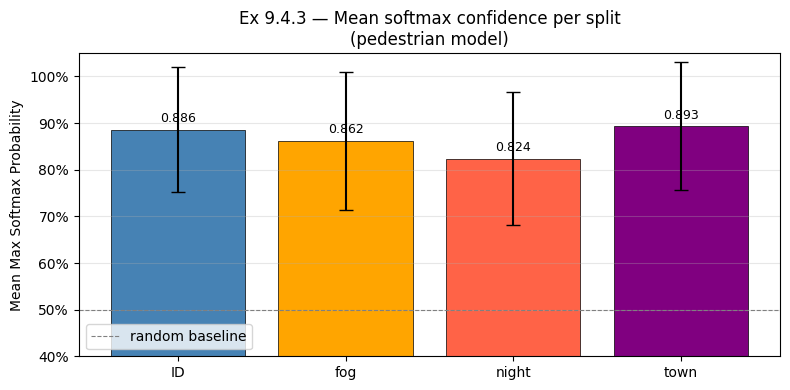


Interpretation:
  If the model is more confident on ID than OOD, mean MSP should be higher
  for the ID split.  In practice, models trained with cross-entropy often
  remain overconfident on OOD inputs — MSP does NOT reliably drop for
  out-of-distribution images, which motivates better detectors (Ex 9.6/9.7).



In [21]:
# We use the PEDESTRIAN model as the representative model for all OOD experiments
# (Exercise 9.6 instruction: "Pick any one of your three models")
REF_TASK  = 'pedestrian'
REF_MODEL = MODELS[REF_TASK]

print(f'Reference model: {REF_TASK}')
print('=' * 60)
print(f'  {"Split":<12}  {"Mean MSP":>10}  {"Std MSP":>10}  {"N":>6}')
print('-' * 60)

conf_results = {}
for split_name in SPLITS:
    loader = make_loader(split_name, REF_TASK)
    msp    = get_msp_scores(REF_MODEL, loader)
    conf_results[split_name] = msp
    print(f'  {split_name:<12}  {msp.mean():>10.4f}  {msp.std():>10.4f}  {len(msp):>6}')

# Bar chart: mean confidence per split
splits_sorted = ['ID'] + OOD_NAMES
colors = ['steelblue'] + ['orange', 'tomato', 'purple'][:len(OOD_NAMES)]
means  = [conf_results[s].mean() for s in splits_sorted]
stds   = [conf_results[s].std()  for s in splits_sorted]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(splits_sorted, means, color=colors, yerr=stds,
              capsize=5, edgecolor='black', linewidth=0.5)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Mean Max Softmax Probability')
ax.set_title(f'Ex 9.4.3 — Mean softmax confidence per split\n({REF_TASK} model)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random baseline')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/results/9_4_mean_confidence.png', dpi=130, bbox_inches='tight')
plt.show()

print("""
Interpretation:
  If the model is more confident on ID than OOD, mean MSP should be higher
  for the ID split.  In practice, models trained with cross-entropy often
  remain overconfident on OOD inputs — MSP does NOT reliably drop for
  out-of-distribution images, which motivates better detectors (Ex 9.6/9.7).
""")

---
## 📉 Cell 8 — Exercise 9.6: MSP baseline AUROC

Exercise 9.6 — MSP Baseline AUROC
  Model: pedestrian
  ID split: 3600 images

  fog       AUROC = 0.5660
  night     AUROC = 0.6656
  town      AUROC = 0.4793


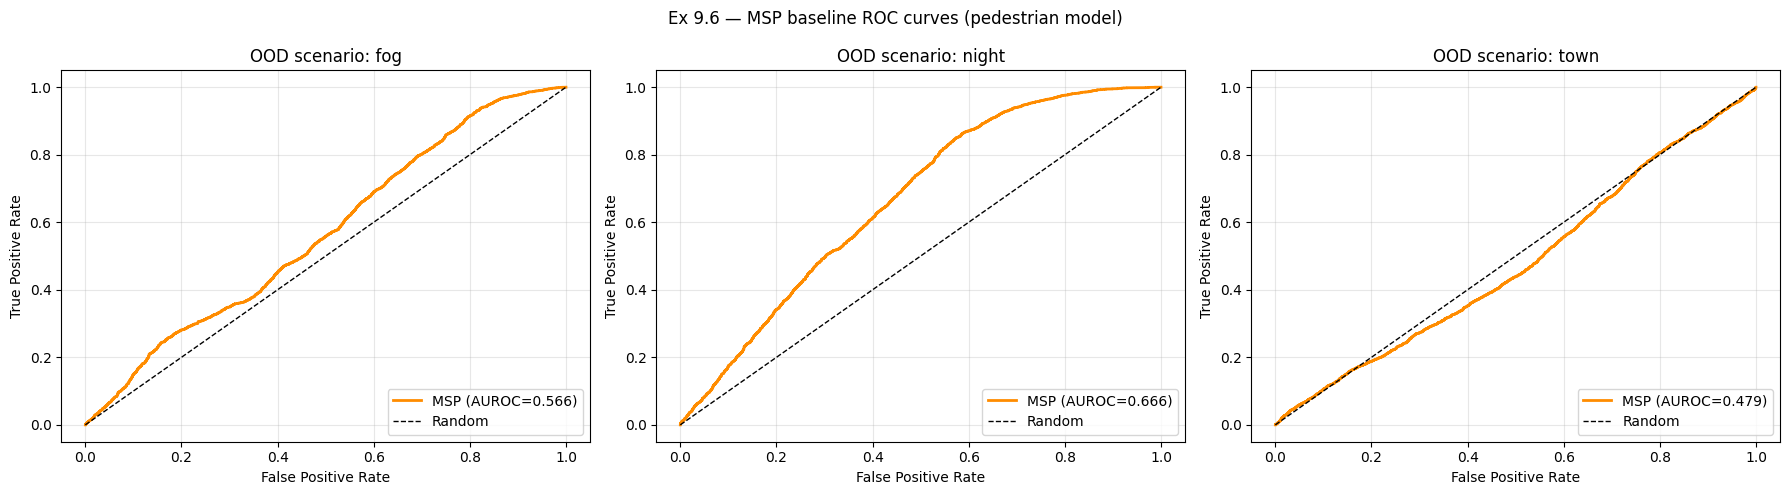

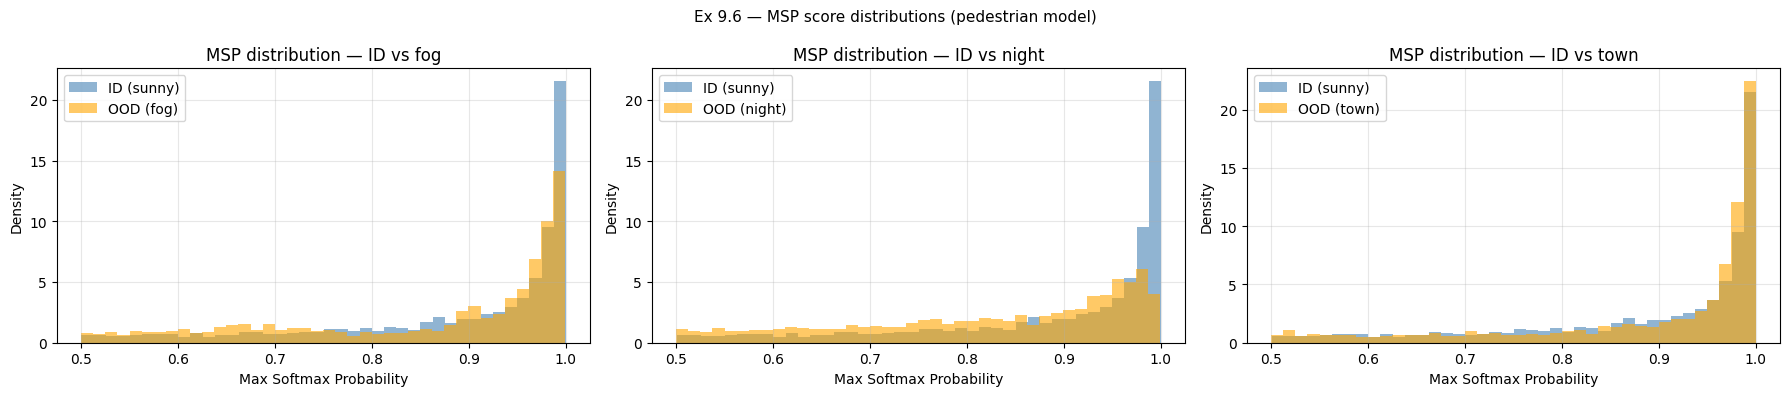

In [22]:
# ID MSP scores (high MSP = in-distribution)
id_msp = conf_results['ID']

print('Exercise 9.6 — MSP Baseline AUROC')
print('=' * 55)
print(f'  Model: {REF_TASK}')
print(f'  ID split: {len(id_msp)} images')
print()

fig, axes = plt.subplots(1, len(OOD_NAMES), figsize=(6 * len(OOD_NAMES), 5))
if len(OOD_NAMES) == 1: axes = [axes]

msp_auroc = {}
for ax, ood_name in zip(axes, OOD_NAMES):
    ood_msp = conf_results[ood_name]

    # Labels: 0 = ID (high MSP = in-dist), 1 = OOD (low MSP)
    # For roc_auc_score the score should be higher for the positive class.
    # We define OOD as positive (label=1) and use NEGATIVE MSP as score
    # so that low confidence → high score → correctly ranked as OOD.
    scores = np.concatenate([-id_msp, -ood_msp])
    labels = np.concatenate([np.zeros(len(id_msp)), np.ones(len(ood_msp))])

    auroc = roc_auc_score(labels, scores)
    msp_auroc[ood_name] = auroc
    fpr, tpr, _ = roc_curve(labels, scores)

    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'MSP (AUROC={auroc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'OOD scenario: {ood_name}')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    print(f'  {ood_name:<8}  AUROC = {auroc:.4f}')

plt.suptitle(f'Ex 9.6 — MSP baseline ROC curves ({REF_TASK} model)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/results/9_6_msp_roc.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Score distribution plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, len(OOD_NAMES), figsize=(6 * len(OOD_NAMES), 4))
if len(OOD_NAMES) == 1: axes = [axes]
for ax, ood_name in zip(axes, OOD_NAMES):
    ood_msp = conf_results[ood_name]
    ax.hist(id_msp,  bins=40, alpha=0.6, color='steelblue', label='ID (sunny)',    density=True)
    ax.hist(ood_msp, bins=40, alpha=0.6, color='orange',    label=f'OOD ({ood_name})', density=True)
    ax.set_xlabel('Max Softmax Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'MSP distribution — ID vs {ood_name}')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f'Ex 9.6 — MSP score distributions ({REF_TASK} model)', fontsize=11)
plt.tight_layout()
plt.savefig('/content/results/9_6_msp_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 🔬 Cell 9 — Exercise 9.7: Feature-based OOD detection (Mahalanobis distance)

In [23]:
print('Exercise 9.7 — Mahalanobis-distance OOD detector')
print('=' * 60)
print('Step 1: Extracting deep features (ResNet-18 avgpool, 512-d)...')

feat_model = get_feature_extractor(MODELS[REF_TASK])

# ── 9.7.1: Extract features ─────────────────────────────────────────────────
id_loader = make_loader('ID', REF_TASK)
id_feats  = extract_features(feat_model, id_loader)
print(f'  ID features shape: {id_feats.shape}')

ood_feats = {}
for ood_name in OOD_NAMES:
    loader = make_loader(ood_name, REF_TASK)
    ood_feats[ood_name] = extract_features(feat_model, loader)
    print(f'  {ood_name:<8} features shape: {ood_feats[ood_name].shape}')

# ── 9.7.2: Fit Mahalanobis detector on ID features ──────────────────────────
print('\nStep 2: Fitting Mahalanobis detector on ID features...')
cov_est   = EmpiricalCovariance(assume_centered=False)
cov_est.fit(id_feats)
mu        = cov_est.location_          # mean vector
cov_inv   = cov_est.precision_         # inverse covariance

def mahalanobis_score(feats, mu, cov_inv):
    """Mahalanobis distance for each row in feats. Higher = more OOD."""
    diff = feats - mu[np.newaxis, :]                       # (N, D)
    left = diff @ cov_inv                                  # (N, D)
    dist = np.sqrt(np.sum(left * diff, axis=1))            # (N,)
    return dist

id_mah  = mahalanobis_score(id_feats, mu, cov_inv)
ood_mah = {name: mahalanobis_score(ood_feats[name], mu, cov_inv)
           for name in OOD_NAMES}

print(f'  ID   Mahal dist  mean={id_mah.mean():.2f}  std={id_mah.std():.2f}')
for name, scores in ood_mah.items():
    print(f'  {name:<8} Mahal dist  mean={scores.mean():.2f}  std={scores.std():.2f}')

Exercise 9.7 — Mahalanobis-distance OOD detector
Step 1: Extracting deep features (ResNet-18 avgpool, 512-d)...
  ID features shape: (3600, 512)
  fog      features shape: (3600, 512)
  night    features shape: (3600, 512)
  town     features shape: (3600, 512)

Step 2: Fitting Mahalanobis detector on ID features...
  ID   Mahal dist  mean=21.80  std=6.07
  fog      Mahal dist  mean=43.44  std=4.70
  night    Mahal dist  mean=52.84  std=6.37
  town     Mahal dist  mean=36.63  std=4.46


## 📈 Cell 10 — Exercise 9.7: AUROC comparison MSP vs Mahalanobis

Step 3: AUROC — MSP vs Mahalanobis
  OOD scenario     MSP AUROC    Mahal AUROC       Gap
--------------------------------------------------
  fog               0.5660         0.9997  + 0.4338
  night             0.6656         1.0000  + 0.3344
  town              0.4793         0.9888  + 0.5095

  Largest gap: town (Δ = +0.5095)


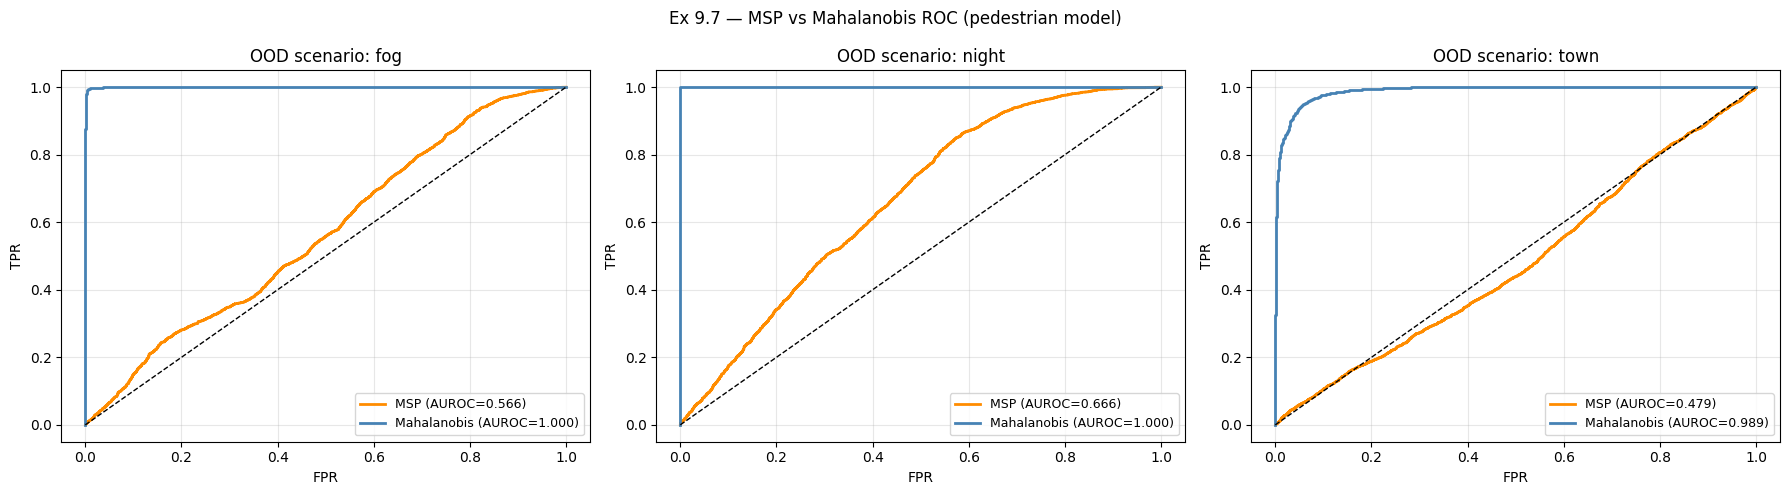

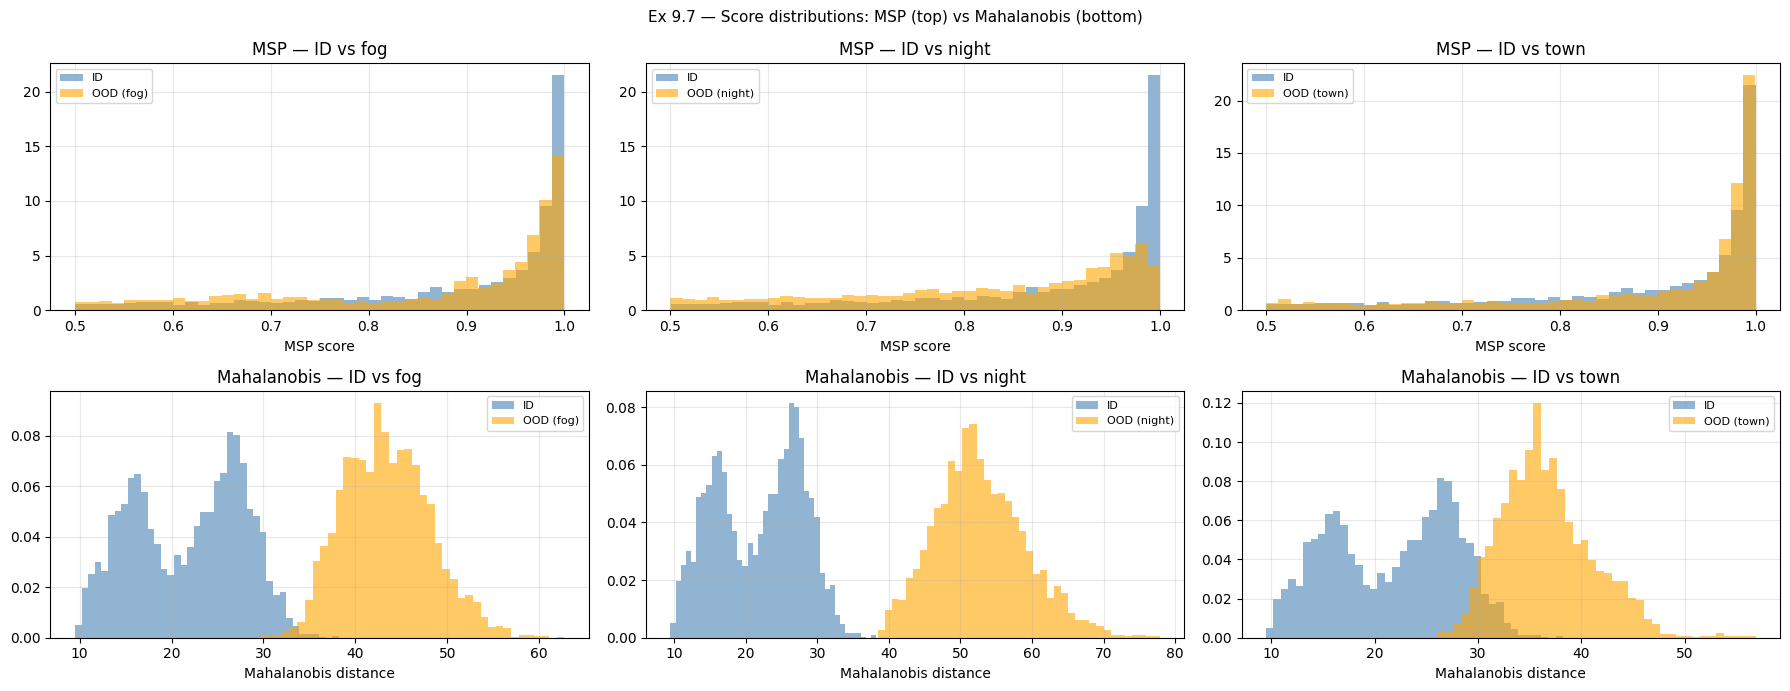

In [24]:
print('Step 3: AUROC — MSP vs Mahalanobis')
print('=' * 60)
print(f'  {"OOD scenario":<10}  {"MSP AUROC":>12}  {"Mahal AUROC":>13}  {"Gap":>8}')
print('-' * 50)

mah_auroc = {}
for ood_name in OOD_NAMES:
    ood_m  = ood_mah[ood_name]
    # Mahalanobis: higher = more OOD → positive class
    scores = np.concatenate([id_mah, ood_m])
    labels = np.concatenate([np.zeros(len(id_mah)), np.ones(len(ood_m))])
    auroc  = roc_auc_score(labels, scores)
    mah_auroc[ood_name] = auroc
    gap    = auroc - msp_auroc[ood_name]
    sign   = '+' if gap >= 0 else ''
    print(f'  {ood_name:<10}  {msp_auroc[ood_name]:>12.4f}  {auroc:>13.4f}  '
          f'{sign}{gap:>7.4f}')

best_gap_name = max(OOD_NAMES, key=lambda n: mah_auroc[n] - msp_auroc[n])
print(f'\n  Largest gap: {best_gap_name} '
      f'(Δ = {mah_auroc[best_gap_name]-msp_auroc[best_gap_name]:+.4f})')

# ── Combined ROC plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(OOD_NAMES), figsize=(6 * len(OOD_NAMES), 5))
if len(OOD_NAMES) == 1: axes = [axes]

for ax, ood_name in zip(axes, OOD_NAMES):
    # MSP ROC
    msp_scores = np.concatenate([-id_msp, -conf_results[ood_name]])
    msp_labels = np.concatenate([np.zeros(len(id_msp)),
                                  np.ones(len(conf_results[ood_name]))])
    fpr_m, tpr_m, _ = roc_curve(msp_labels, msp_scores)

    # Mahalanobis ROC
    mah_scores = np.concatenate([id_mah, ood_mah[ood_name]])
    mah_labels = np.concatenate([np.zeros(len(id_mah)),
                                  np.ones(len(ood_mah[ood_name]))])
    fpr_k, tpr_k, _ = roc_curve(mah_labels, mah_scores)

    ax.plot(fpr_m, tpr_m, color='darkorange', lw=2,
            label=f'MSP (AUROC={msp_auroc[ood_name]:.3f})')
    ax.plot(fpr_k, tpr_k, color='steelblue', lw=2,
            label=f'Mahalanobis (AUROC={mah_auroc[ood_name]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'OOD scenario: {ood_name}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'Ex 9.7 — MSP vs Mahalanobis ROC ({REF_TASK} model)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/results/9_7_msp_vs_mahal_roc.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Score distribution comparison ────────────────────────────────────────
fig, axes = plt.subplots(2, len(OOD_NAMES), figsize=(6 * len(OOD_NAMES), 7))
if len(OOD_NAMES) == 1: axes = axes[:, np.newaxis]

for col, ood_name in enumerate(OOD_NAMES):
    # MSP distributions
    ood_msp = conf_results[ood_name]
    axes[0, col].hist(id_msp,  bins=40, alpha=0.6, density=True,
                      color='steelblue', label='ID')
    axes[0, col].hist(ood_msp, bins=40, alpha=0.6, density=True,
                      color='orange', label=f'OOD ({ood_name})')
    axes[0, col].set_title(f'MSP — ID vs {ood_name}')
    axes[0, col].set_xlabel('MSP score'); axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    # Mahalanobis distributions
    axes[1, col].hist(id_mah,            bins=40, alpha=0.6, density=True,
                      color='steelblue', label='ID')
    axes[1, col].hist(ood_mah[ood_name], bins=40, alpha=0.6, density=True,
                      color='orange', label=f'OOD ({ood_name})')
    axes[1, col].set_title(f'Mahalanobis — ID vs {ood_name}')
    axes[1, col].set_xlabel('Mahalanobis distance'); axes[1, col].legend(fontsize=8)
    axes[1, col].grid(alpha=0.3)

plt.suptitle('Ex 9.7 — Score distributions: MSP (top) vs Mahalanobis (bottom)',
             fontsize=11)
plt.tight_layout()
plt.savefig('/content/results/9_7_score_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 📋 Cell 11 — Exercise 9.8: Extend STPA safety analysis

In [25]:
print("""
═══════════════════════════════════════════════════════════════════════════════
Exercise 9.8 — Extended System-Theoretic Process Analysis (STPA) for OOD Risk
═══════════════════════════════════════════════════════════════════════════════

9.8.1  HAZARD
──────────────
Existing hazard H1 (from Sheet 2):
  "Vehicle fails to brake for a pedestrian in its path."

New / refined hazard H2 (OOD-specific):
  "Vehicle acts on unreliable perception output produced while the camera
   input is outside the trained operational design domain (e.g. fog, night,
   unseen environment), without detecting that the perception is untrustworthy."

  H2 is a causal contributor to H1: if the pedestrian detector receives a
  fog image and silently outputs "no pedestrian", H1 follows as a consequence.

───────────────────────────────────────────────────────────────────────────────
9.8.2  UNSAFE CONTROL ACTION (UCA)
────────────────────────────────────
UCA-OOD-1:
  Controller: Planner / motion controller
  Control action: CONTINUE AT SPEED (no brake command issued)
  Context: Camera input is out-of-ODD (fog / night / unseen town) AND the
           OOD monitor does not flag the input AND the perception pipeline
           outputs a prediction as if the input were valid.
  Why unsafe: The planner relies on untrustworthy perception output with no
              indication that a hazard (undetected pedestrian) may be present.
  Linked hazards: H1, H2

───────────────────────────────────────────────────────────────────────────────
9.8.3  SAFETY CONSTRAINTS
──────────────────────────
Model-level constraint (OOD monitor):
  SC-OOD-1: The OOD monitor SHALL flag any input whose OOD score exceeds
  a calibrated threshold τ with a false-negative rate ≤ 5 % on all known
  OOD scenarios (fog, night) at FPR ≤ 10 % on in-distribution inputs.
  Justification: Given the severity of H1 (potential fatality), even a 5 %
  miss rate for OOD detections is only tolerable if combined with the
  system-level constraint below. A stricter threshold reduces false negatives
  but increases false alarms that degrade availability.

System-level constraint (response):
  SC-OOD-2: When the OOD monitor raises an alert, the motion controller
  SHALL immediately reduce speed to ≤ 5 km/h and issue a request for
  human supervision or bring the vehicle to a safe stop within 3 seconds.
  Perception outputs produced during an OOD-flagged interval SHALL NOT be
  used as sole input to safety-critical decisions (braking, lane change).

───────────────────────────────────────────────────────────────────────────────
9.8.4  RESIDUAL RISK
──────────────────────
Even with a perfect OOD detector (AUROC = 1.0, zero false negatives), the
following residual risks remain:

1. Detection latency: There is a delay between when the vehicle enters an
   OOD condition and when the monitor raises an alert (at least one inference
   cycle). During this window the system acts on untrustworthy output.

2. Safe fallback failure: SC-OOD-2 requires the vehicle to slow down safely.
   If the OOD condition itself impairs sensors used for the fallback (e.g.
   heavy fog also impairs LiDAR), the fallback manoeuvre may itself be unsafe.

3. Unknown unknowns: The OOD detector is validated on known OOD types (fog,
   night, new town). A genuinely novel OOD type (e.g. sensor hardware fault,
   extreme rain, road markings painted on camera) may not be detected if it
   lies outside the detector's own training/calibration distribution.

4. UCA not fully addressed: UCA-OOD-1 requires both detection AND a correct
   safe response. SC-OOD-1 addresses detection; SC-OOD-2 addresses response.
   Residual risk remains from the interaction of both constraints failing
   simultaneously — e.g. monitor correctly flags OOD but the safe-stop
   actuator malfunctions. A separate actuator-fault analysis is needed.

Conclusion: OOD detection reduces but does NOT eliminate the hazard.
It must be combined with redundant sensing, conservative fallback behaviours,
geofencing (restrict operational domain), and regular re-validation as the
fleet encounters new environments.
═══════════════════════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════════════════════
Exercise 9.8 — Extended System-Theoretic Process Analysis (STPA) for OOD Risk
═══════════════════════════════════════════════════════════════════════════════

9.8.1  HAZARD
──────────────
Existing hazard H1 (from Sheet 2):
  "Vehicle fails to brake for a pedestrian in its path."

New / refined hazard H2 (OOD-specific):
  "Vehicle acts on unreliable perception output produced while the camera
   input is outside the trained operational design domain (e.g. fog, night,
   unseen environment), without detecting that the perception is untrustworthy."

  H2 is a causal contributor to H1: if the pedestrian detector receives a
  fog image and silently outputs "no pedestrian", H1 follows as a consequence.

───────────────────────────────────────────────────────────────────────────────
9.8.2  UNSAFE CONTROL ACTION (UCA)
────────────────────────────────────
UCA-OOD-1:
  Controller: Planner / motion controller
  Contr

---
## 📊 Cell 12 — Summary table: all AUROC results


=== AUROC Summary ===
  Model: pedestrian
  OOD Scenario     MSP AUROC    Mahal AUROC    Better
----------------------------------------------------
  fog                 0.5660         0.9997     Mahal
  night               0.6656         1.0000     Mahal


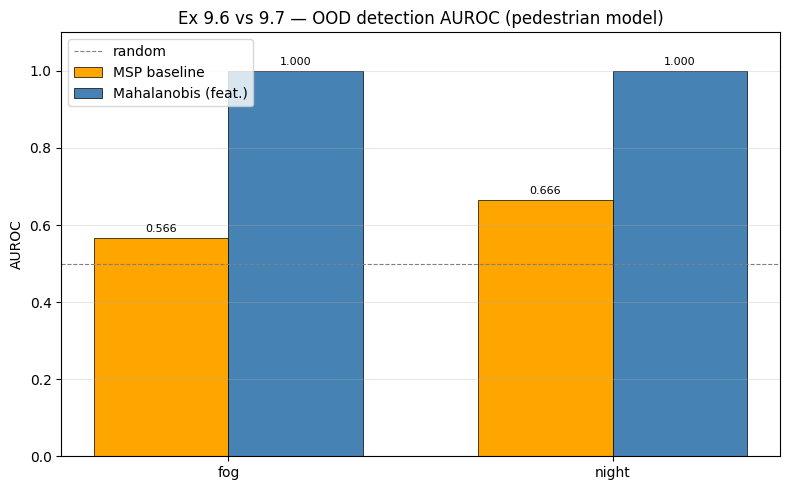

In [ ]:
print('\n=== AUROC Summary ===')
print(f'  Model: {REF_TASK}')
print(f'  {"OOD Scenario":<12}  {"MSP AUROC":>12}  {"Mahal AUROC":>13}  {"Better":>8}')
print('-' * 52)
for ood_name in OOD_NAMES:
    msp_a = msp_auroc[ood_name]
    mah_a = mah_auroc[ood_name]
    better = 'Mahal' if mah_a > msp_a else 'MSP'
    print(f'  {ood_name:<12}  {msp_a:>12.4f}  {mah_a:>13.4f}  {better:>8}')

# Grouped bar chart
x = np.arange(len(OOD_NAMES))
w = 0.35
fig, ax = plt.subplots(figsize=(max(6, 4*len(OOD_NAMES)), 5))
ax.bar(x - w/2, [msp_auroc[n] for n in OOD_NAMES], w,
       label='MSP baseline',       color='orange',    edgecolor='black', lw=0.5)
ax.bar(x + w/2, [mah_auroc[n] for n in OOD_NAMES], w,
       label='Mahalanobis (feat.)', color='steelblue', edgecolor='black', lw=0.5)
ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, label='random')
ax.set_xticks(x); ax.set_xticklabels(OOD_NAMES)
ax.set_ylim(0, 1.1); ax.set_ylabel('AUROC')
ax.set_title(f'Ex 9.6 vs 9.7 — OOD detection AUROC ({REF_TASK} model)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, ood_name in enumerate(OOD_NAMES):
    ax.text(i - w/2, msp_auroc[ood_name] + 0.01,
            f'{msp_auroc[ood_name]:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + w/2, mah_auroc[ood_name] + 0.01,
            f'{mah_auroc[ood_name]:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('/content/results/9_summary_auroc.png', dpi=130, bbox_inches='tight')
plt.show()

## 💾 Cell 13 — Download all result figures

In [ ]:
import shutil

print('=== Saved figures ===')
for f in sorted(glob.glob('/content/results/*.png')):
    print(f'  {f}')

shutil.make_archive('/content/sheet9_results', 'zip', '/content', 'results')

from google.colab import files
files.download('/content/sheet9_results.zip')
print('\n✅ Done — sheet9_results.zip downloaded.')

=== Saved figures ===
  /content/results/9_4_distribution_shift.png
  /content/results/9_4_mean_confidence.png
  /content/results/9_6_msp_distributions.png
  /content/results/9_6_msp_roc.png
  /content/results/9_7_msp_vs_mahal_roc.png
  /content/results/9_7_score_distributions.png
  /content/results/9_summary_auroc.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done — sheet9_results.zip downloaded.
